=== 电化学绘图工具（C-rate Test + CV）===



请输入数据文件夹路径（例如 C:\Users\Public\Echem\LEI）:  /Users/leili/Downloads/lto-0746
请输入活性物质质量（mg）:  0.0746



─── 图 1：C-rate Test ───
处理: 2c  →  2c.xlsx
处理: 5c  →  5c.xlsx
处理: 10c  →  10c.xlsx
处理: 20c  →  20c.xlsx
处理: 1c-f  →  1c-f.xlsx
→ 已保存: /Users/leili/Downloads/lto-0746/c_rate_test.png


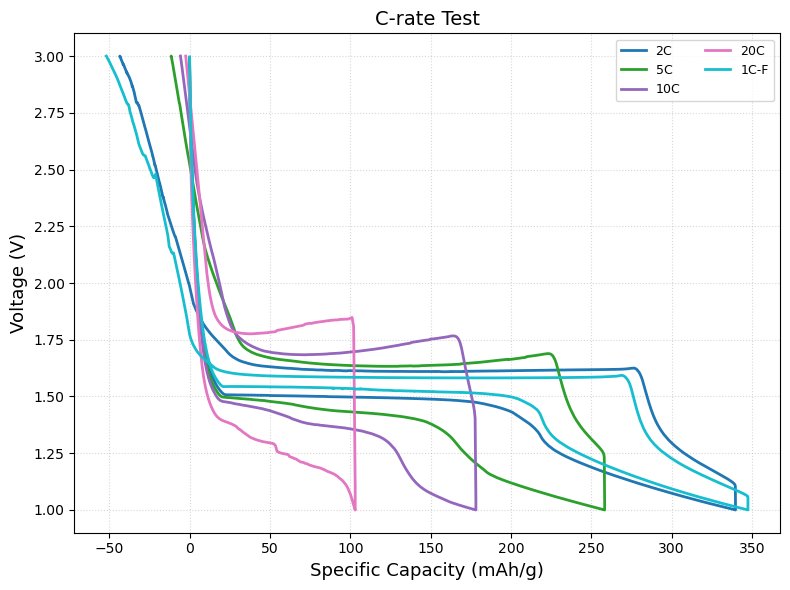


─── 图 2：Cyclic Voltammetry ───
处理: cv.xlsx
→ 已保存: /Users/leili/Downloads/lto-0746/cv.png


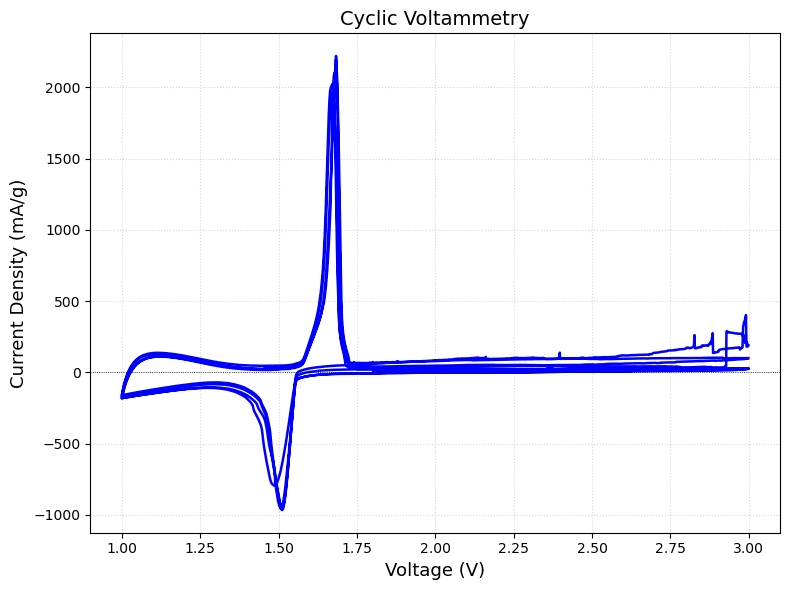

In [11]:
# -*- coding: utf-8 -*-
"""
电化学绘图脚本：C-rate Test + CV
======================================

【文件命名规范】（供使用者参考）
----------------------------------
所有文件放在同一文件夹内，命名格式如下：

  倍率充放电文件：
    1c.xlsx
    2c.xlsx
    5c.xlsx
    10c.xlsx
    ...（数字 + 小写 c + .xlsx）

  末尾回测文件（最后一次重新跑 1C）：
    1c-f.xlsx

  CV 文件：
    cv.xlsx

【数据格式】
----------------------------------
1. Rate 文件：
   第一行为文件路径（忽略）
   第二行为列名，例如：
       time/s    <I>/mA    Ewe/V vs. SCE
   第三行起为数值数据

2. CV 文件：
   第一行为文件路径（忽略）
   第二行为列名，例如：
       Ewe/V vs. SCE    <I>/mA
   第三行起为数值数据

【脚本逻辑】
----------------------------------
1. C-rate 文件默认应有 3 个完整 cycle
2. 不能把整份数据平均分成 3 份
3. 根据电流正负变化识别真实 cycle
4. 可选：
   - 只画第 2 个 cycle
   - 画所有 cycle
5. 对一个完整 cycle：
   Q 连续，先增大，再减小
6. CV 不切 cycle，直接整份画
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm


# =========================
# 用户可改参数
# =========================
PLOT_ALL_CYCLES = False   # False: 只画第2个cycle；True: 画所有cycle
ZERO_TOL_RATIO = 0.05     # 去掉接近0电流的静置段
LINEWIDTH = 2
FIGSIZE = (8, 6)
SAVE_DPI = 150
PLOT_ALL_CYCLES = False   # False: 只画第2个cycle；True: 画所有cycle

# 用户自己定义要画哪些 rate
# None = 画全部
# 例1：只画 2c 及后面
# SELECT_RATES = ['2c', '5c', '10c', '20c', '1c-f']
# 例2：只画某几个
# SELECT_RATES = ['1c', '5c', '1c-f']
SELECT_RATES = ['2c', '5c', '10c', '20c', '1c-f']


# ──────────────────────────────────────────────
# 1. 读取 rate xlsx
# ──────────────────────────────────────────────
def load_rate_xlsx(filepath):
    """
    读取 rate 文件
    第1行：文件路径（跳过）
    第2行：列名
    第3行起：数据
    需要列：time/s, <I>/mA, Ewe/V vs. SCE
    """
    df = pd.read_excel(filepath, skiprows=1, header=0)
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    for c in df.columns:
        cl = c.lower()
        if 'time' in cl:
            col_map[c] = 'time_s'
        elif '<i>' in cl or 'current' in cl:
            col_map[c] = 'I_mA'
        elif 'ewe' in cl or 'voltage' in cl or cl == 'v':
            col_map[c] = 'V'

    df = df.rename(columns=col_map)

    needed = ['time_s', 'I_mA', 'V']
    for col in needed:
        if col not in df.columns:
            raise ValueError(f'Rate 文件缺少列: {col}；实际列名为 {list(df.columns)}')

    df = df[needed].dropna()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    return df.reset_index(drop=True)


# ──────────────────────────────────────────────
# 2. 读取 CV xlsx
# ──────────────────────────────────────────────
def load_cv_xlsx(filepath):
    """
    读取 CV 文件
    第1行：文件路径（跳过）
    第2行：列名
    第3行起：数据
    需要列：Ewe/V vs. SCE, <I>/mA
    """
    df = pd.read_excel(filepath, skiprows=1, header=0)
    df.columns = [str(c).strip() for c in df.columns]

    col_map = {}
    for c in df.columns:
        cl = c.lower()
        if '<i>' in cl or 'current' in cl:
            col_map[c] = 'I_mA'
        elif 'ewe' in cl or 'voltage' in cl or cl == 'v':
            col_map[c] = 'V'

    df = df.rename(columns=col_map)

    needed = ['V', 'I_mA']
    for col in needed:
        if col not in df.columns:
            raise ValueError(f'CV 文件缺少列: {col}；实际列名为 {list(df.columns)}')

    df = df[needed].dropna()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    return df.reset_index(drop=True)


# ──────────────────────────────────────────────
# 3. 根据电流方向识别真实 cycle
# ──────────────────────────────────────────────
def split_cycles(df, zero_tol_ratio=0.05):
    """
    根据电流正负变化识别真实 cycle
    先去掉接近 0 的静置点，再切成半周期，
    每相邻两段合并成一个完整 cycle
    """
    i = df['I_mA'].values.astype(float)
    max_abs_i = np.max(np.abs(i))

    if max_abs_i == 0:
        return []

    zero_tol = max_abs_i * zero_tol_ratio
    mask = np.abs(i) > zero_tol
    df2 = df.loc[mask].reset_index(drop=True)

    if len(df2) < 10:
        return []

    signs = np.sign(df2['I_mA'].values)
    changes = np.where(np.diff(signs) != 0)[0] + 1

    half_cycles = []
    prev = 0
    for idx in changes:
        seg = df2.iloc[prev:idx].reset_index(drop=True)
        if len(seg) > 5:
            half_cycles.append(seg)
        prev = idx

    last_seg = df2.iloc[prev:].reset_index(drop=True)
    if len(last_seg) > 5:
        half_cycles.append(last_seg)

    cycles = []
    j = 0
    while j + 1 < len(half_cycles):
        cyc = pd.concat([half_cycles[j], half_cycles[j + 1]], ignore_index=True)
        cycles.append(cyc)
        j += 2

    return cycles


# ──────────────────────────────────────────────
# 4. 对完整 cycle 计算连续容量
#    Q 先增大，再减小
# ──────────────────────────────────────────────
def calc_specific_capacity_cycle(seg, mass_mg, zero_tol_ratio=0.05):
    """
    对一个完整 cycle 计算连续容量 Q：
    前半段 Q 递增，后半段 Q 递减
    这样 voltage-capacity 图会表现为：
    Q 连续，先增大，再减小
    """
    mass_g = mass_mg / 1000.0

    t = seg['time_s'].values.astype(float)
    i = seg['I_mA'].values.astype(float)
    v = seg['V'].values.astype(float)

    if len(t) < 2:
        return np.array([]), np.array([])

    max_abs_i = np.max(np.abs(i))
    if max_abs_i == 0:
        return np.array([]), np.array([])

    zero_tol = max_abs_i * zero_tol_ratio
    mask = np.abs(i) > zero_tol

    t = t[mask]
    i = i[mask]
    v = v[mask]

    if len(t) < 2:
        return np.array([]), np.array([])

    signs = np.sign(i)
    switch_idx = np.where(np.diff(signs) != 0)[0]

    # 如果找不到切换点，退化成单调容量
    if len(switch_idx) == 0:
        dt = np.diff(t, prepend=t[0])
        dt[0] = 0
        dQ = np.abs(i) * dt / 3600.0
        cap = np.cumsum(dQ) / mass_g
        return cap, v

    split_pt = switch_idx[0] + 1

    # 前半段：Q递增
    t1 = t[:split_pt]
    i1 = i[:split_pt]
    v1 = v[:split_pt]

    dt1 = np.diff(t1, prepend=t1[0])
    dt1[0] = 0
    dQ1 = np.abs(i1) * dt1 / 3600.0
    cap1 = np.cumsum(dQ1) / mass_g

    # 后半段：Q递减
    t2 = t[split_pt:]
    i2 = i[split_pt:]
    v2 = v[split_pt:]

    dt2 = np.diff(t2, prepend=t2[0])
    dt2[0] = 0
    dQ2 = np.abs(i2) * dt2 / 3600.0
    cap2 = cap1[-1] - np.cumsum(dQ2) / mass_g

    cap = np.concatenate([cap1, cap2])
    volt = np.concatenate([v1, v2])

    return cap, volt


# ──────────────────────────────────────────────
# 5. 扫描倍率文件
# ──────────────────────────────────────────────
def discover_rate_files(folder, selected_rates=None):
    """
    扫描文件夹，返回有序的 (label, path)
    排序规则：
      1c, 2c, 5c, 10c, ...
      最后再放 1c-f

    selected_rates:
      None -> 全部
      list -> 只保留用户指定的 rate，如 ['2c', '5c', '1c-f']
    """
    pattern = os.path.join(folder, '*.xlsx')
    files = glob.glob(pattern)

    rate_files = []
    final_file = None

    for f in files:
        name = os.path.splitext(os.path.basename(f))[0].lower()

        if name == 'cv':
            continue

        if re.match(r'^\d+(\.\d+)?c-f$', name):
            final_file = (name, f)

        elif re.match(r'^\d+(\.\d+)?c$', name):
            num = float(re.match(r'^(\d+(\.\d+)?)c$', name).group(1))
            rate_files.append((num, name, f))

    rate_files.sort(key=lambda x: x[0])
    ordered = [(label, path) for _, label, path in rate_files]

    if final_file:
        ordered.append(final_file)

    # 如果用户指定了要画哪些 rate，就过滤
    if selected_rates is not None:
        selected_rates = [x.lower() for x in selected_rates]
        ordered = [(label, path) for label, path in ordered if label.lower() in selected_rates]

    return ordered


# ──────────────────────────────────────────────
# 6. 画 C-rate test
# ──────────────────────────────────────────────
def plot_c_rate_test(folder, mass_mg, plot_all_cycles=False):
    rate_files = discover_rate_files(folder, selected_rates=SELECT_RATES)

    if not rate_files:
        print("未找到符合命名规范的倍率 xlsx 文件，跳过 C-rate 图。")
        return

    fig, ax = plt.subplots(figsize=FIGSIZE)
    colors = cm.tab10(np.linspace(0, 0.9, len(rate_files)))

    for color, (label, filepath) in zip(colors, rate_files):
        print(f"处理: {label}  →  {os.path.basename(filepath)}")

        try:
            df = load_rate_xlsx(filepath)
        except Exception as e:
            print(f"  [跳过] 读取失败: {e}")
            continue

        cycles = split_cycles(df, zero_tol_ratio=ZERO_TOL_RATIO)

        if len(cycles) != 3:
            print(f"  [警告] {label} 识别到 {len(cycles)} 个 cycle（默认应为 3 个）")

        if len(cycles) == 0:
            print(f"  [跳过] {label} 没有可用 cycle")
            continue

        if plot_all_cycles:
            line_styles = ['-', '--', ':', '-.']
            for idx, cyc in enumerate(cycles, start=1):
                cap, volt = calc_specific_capacity_cycle(
                    cyc.reset_index(drop=True),
                    mass_mg,
                    zero_tol_ratio=ZERO_TOL_RATIO
                )
                if len(cap) == 0:
                    continue

                ax.plot(
                    cap,
                    volt,
                    color=color,
                    linestyle=line_styles[(idx - 1) % len(line_styles)],
                    linewidth=LINEWIDTH,
                    alpha=0.9,
                    label=f"{label.upper()} cycle {idx}"
                )
        else:
            if len(cycles) < 2:
                print(f"  [跳过] {label} 无法提取第 2 个 cycle")
                continue

            cycle2 = cycles[1].reset_index(drop=True)
            cap, volt = calc_specific_capacity_cycle(
                cycle2,
                mass_mg,
                zero_tol_ratio=ZERO_TOL_RATIO
            )
            if len(cap) == 0:
                print(f"  [跳过] {label} 第2个cycle容量计算失败")
                continue

            ax.plot(
                cap,
                volt,
                color=color,
                linewidth=LINEWIDTH,
                label=label.upper()
            )

    ax.set_xlabel('Specific Capacity (mAh/g)', fontsize=13)
    ax.set_ylabel('Voltage (V)', fontsize=13)

    if plot_all_cycles:
        ax.set_title('C-rate Test', fontsize=14)
        out_path = os.path.join(folder, 'c_rate_test_all_cycles.png')
    else:
        ax.set_title('C-rate Test', fontsize=14)
        out_path = os.path.join(folder, 'c_rate_test.png')

    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()

    plt.savefig(out_path, dpi=SAVE_DPI)
    print(f"→ 已保存: {out_path}")
    plt.show()


# ──────────────────────────────────────────────
# 7. 画 CV（不切 cycle，直接整份画）
# ──────────────────────────────────────────────
def plot_cv(folder, mass_mg):
    cv_path = os.path.join(folder, 'cv.xlsx')

    if not os.path.exists(cv_path):
        print("未找到 cv.xlsx，跳过 CV 图。")
        return

    print("处理: cv.xlsx")

    try:
        df = load_cv_xlsx(cv_path)
    except Exception as e:
        print(f"[跳过] CV 读取失败: {e}")
        return

    mass_g = mass_mg / 1000.0
    current_density = df['I_mA'].values / mass_g

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(df['V'].values, current_density, color='blue', linewidth=1.8)

    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_xlabel('Voltage (V)', fontsize=13)
    ax.set_ylabel('Current Density (mA/g)', fontsize=13)
    ax.set_title('Cyclic Voltammetry', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()

    out_path = os.path.join(folder, 'cv.png')
    plt.savefig(out_path, dpi=SAVE_DPI)
    print(f"→ 已保存: {out_path}")
    plt.show()


# ──────────────────────────────────────────────
# 8. 主程序入口
# ──────────────────────────────────────────────
if __name__ == '__main__':
    print("=== 电化学绘图工具（C-rate Test + CV）===\n")

    folder = input("请输入数据文件夹路径（例如 C:\\Users\\Public\\Echem\\LEI）: ").strip().strip('"')
    if not os.path.isdir(folder):
        print(f"路径不存在: {folder}")
    else:
        try:
            mass_mg = float(input("请输入活性物质质量（mg）: ").strip())
        except ValueError:
            print("质量输入有误，请输入数字。")
        else:
            print("\n─── 图 1：C-rate Test ───")
            plot_c_rate_test(folder, mass_mg, plot_all_cycles=PLOT_ALL_CYCLES)

            print("\n─── 图 2：Cyclic Voltammetry ───")
            plot_cv(folder, mass_mg)